# Characterizing Aberrations with Optuna

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/tutorials/1-getting-started/DTSG127_characterizing_aberrations_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install deeptrack optuna # Uncomment if running on Colab/Kaggle.

This tutorial demonstrates how to identify the aberration type and aberration coefficient of an optical device using the image of a centered particle. DeepTrack2 lets you simulate a number of different optical aberrations, which you can use to identify aberrations you may find experimental setups.

## 1. Setup

Imports needed for this tutorial.

In [ ]:
import random

import deeptrack as dt
from matplotlib import pyplot as plt
import optuna

## 2. Defining the Aberrations
We gather all aberration types that DeepTrack2 can simulate into a list. 

Aberrations in DeepTrack2 are wrappers of the more general `Zernike` feature, which introduces a phase to the pupil function based on the normalized Zernike polynomials. The property `coefficient` is a multiplier for the respective poynomial in the set of Zernike polynomials.

In [ ]:
# Aberration types that can be simulated in DeepTrack2.
aberration_types = [
    dt.Piston,
    dt.VerticalTilt,
    dt.HorizontalTilt,
    dt.ObliqueAstigmatism,
    dt.Defocus,
    dt.Astigmatism,
    dt.ObliqueTrefoil,
    dt.VerticalComa,
    dt.HorizontalComa,
    dt.Trefoil,
    dt.SphericalAberration
]

## 3. Defining the Features

We define the features needed for this example. 

* `fluorescence_microscope` - Flourescence microscope with a pixel size of 0.1 microns and a 256x256 camera.

* `particle` - Spherical particle centered in the image with 1 micrometer radius.


In [ ]:
IMAGE_SIZE = 256

# Define optics.
fluorescence_microscope = dt.Fluorescence(
    magnification=10,
    resolution=1e-6,
    wavelength=660e-9
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE)
)

# Define scatterer.
particle = dt.Sphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 0 ),
    radius=1e-6
)

## 4. Combining the Features

To view the particle throught the aberrated microscope, we first pick a random aberration from the list and modify the pupil of the `fluorescence_microscope` with `fluorescence_microscope.pupil`.

In [ ]:
# Pick a random aberration from the list.
aberration = random.choice(aberration_types)

# Pick a random aberration strength.
aberration = aberration(
    coefficient=lambda: (2 * np.random.rand() - 1) * 8
)

# Modify the pupil of the microscope with the aberration.
fluorescence_microscope.pupil = aberration

Image the particle through the aberrated microscope.

In [ ]:
reference_image = fluorescence_microscope(particle).resolve().squeeze()
plt.imshow(reference_image, cmap="gray")

print(f"{aberration}")
print(f"Coefficient: {aberration.coefficient()}")
print(f"Radius: {particle.radius()}")

## 5. Preparing the Simulation Function for Optuna

Optuna is a hyperparameter optimization framework which lets us explore a large number of parameters in a simple way. For this tutorial we will restrict the search space to four parameters and use a simple RMSE loss function.


In [ ]:
# Simulation function to return a fluorescence image of the selected parameters.
def simulate_aberrated_image(
    aberration_candidate,
    coefficient,
    radius,
    z,
):
    # Get the aberration type and modify the pupil.
    simulated_aberration = aberration_candidate(coefficient=coefficient)
    fluorescence_microscope.pupil = simulated_aberration

    # Instance the particle with the trial parameters.
    particle = dt.Sphere(
        radius=radius,
        position=(IMAGE_SIZE//2, IMAGE_SIZE//2, z)
    )

    # Image the particle through the aberrated microscope.
    simulated_image = fluorescence_microscope(particle).resolve().squeeze()

    return simulated_image.astype(np.float32)

## 6. Preparing the Workflow for Optuna
The following function defines the search parameters and loss function that will be used in the study.

In [ ]:
def objective(trial):

    # Varies aberration type using the list defined at the start.
    aberration_name = trial.suggest_categorical(
        "aberration_name", [cls.__name__ for cls in aberration_types]
    )
    aberration_type = next(
        cls for cls in aberration_types if cls.__name__ == aberration_name
    )

    # Varies aberration strength.
    coefficient = trial.suggest_float("coefficient", -10, 10) 

    # Varies particle radius.
    radius = trial.suggest_float("radius", 1e-7, 2.1e-6) 

    # Varies particle z-position.
    z = trial.suggest_float("z", -1, 1) 

    # Generates a simulated image with the parameters.
    simulated_image = simulate_aberrated_image(
        aberration_type,
        coefficient,
        radius,
        z,
    )

    # Pixel-wise RMSE comparison between the reference and the simulated image.
    loss = np.sqrt(np.mean(np.square(simulated_image - reference_image) ))

    return loss

## 7. Running the Study
We are now ready to run the Optuna study, which we will do for 200 trials. At each iteration the loss along with the parameters will be printed which allows you to track the progress.

In [ ]:
# Run Optuna study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best Loss:", study.best_value)
print("Best parameters:", study.best_trial.params)

## 8.  Validating the Results
With the trial completed, we want to extract the parameters that minimized the loss function and reproduce the image.

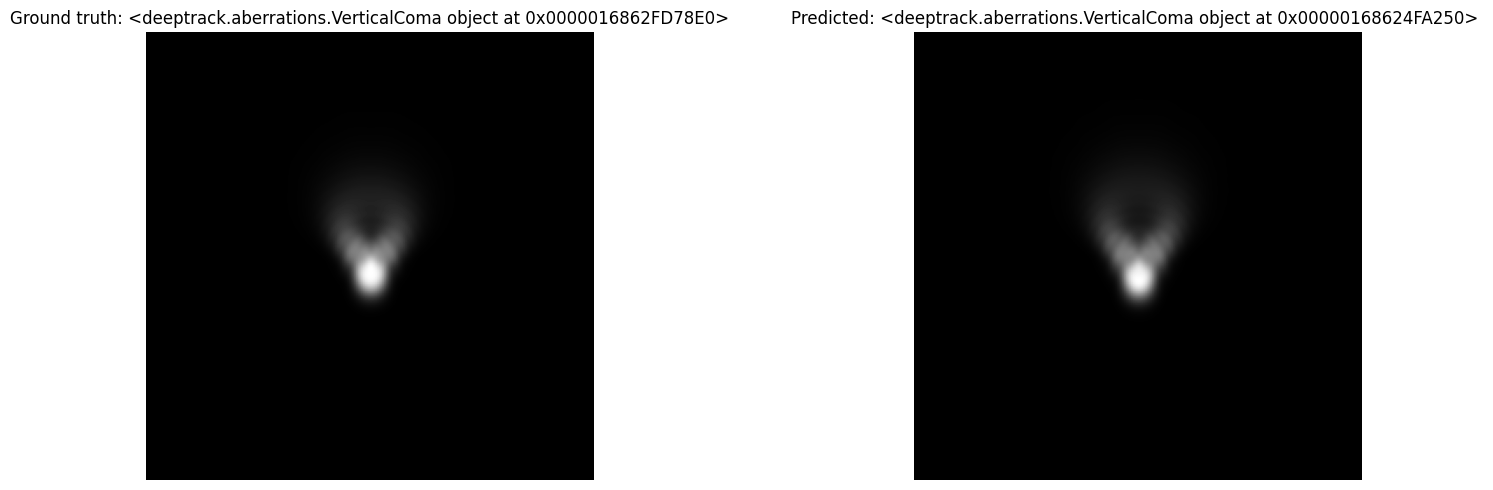

{'aberration_name': 'VerticalComa', 'coefficient': 2.5518046080183736, 'radius': 9.854557858913137e-07, 'focal_distance': 0.847885851248093}


In [ ]:
# Get best parameters from the study.
best_params = study.best_trial.params
coeff = best_params["coefficient"]

# Reconstruct the image which had the optimal parameters.
predicted_aberration = study.best_params["aberration_name"]

# Convert string back to class.
aberration_class = next(
    cls for cls in aberration_types if cls.__name__ == predicted_aberration
)
# Create aberration instance.
predicted_aberration = aberration_class(coefficient=coeff)

optics.pupil = predicted_aberration
predicted_particle = dt.Sphere(
    radius=best_params["radius"],
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, best_params["z"])
)

# Generate predicted image.
predicted_image = optics(predicted_particle).resolve().squeeze()

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(reference_image, cmap="gray")
ax[0].set_title(f"Ground truth: {aberration}")
ax[0].axis("off")

ax[1].imshow(predicted_image, cmap="gray")
ax[1].set_title(f"Predicted: {predicted_aberration} ")
ax[1].axis("off")

plt.tight_layout()
plt.show()
print(best_params)